In [1]:
# ================================================
# CROP YIELD PREDICTION FOR INDIAN FARMERS
# Built by: Nandini Reddy
# BTech CSE - 1st Year
# Description: ML model that predicts crop yield
# based on rainfall, temperature and fertilizer
# Specially designed for Indian agricultural data
# Tools: Python, Scikit-learn, Pandas, Matplotlib
# ================================================

In [2]:
!pip install scikit-learn pandas numpy matplotlib seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [4]:
# Indian Crop Dataset
data = {
    'crop': [
        'Rice','Rice','Rice','Rice','Rice',
        'Wheat','Wheat','Wheat','Wheat','Wheat',
        'Cotton','Cotton','Cotton','Cotton','Cotton',
        'Sugarcane','Sugarcane','Sugarcane','Sugarcane','Sugarcane',
        'Maize','Maize','Maize','Maize','Maize'
    ],
    'rainfall_mm': [
        1200,1100,1300,900,1400,
        600,700,500,800,650,
        700,800,600,900,750,
        1500,1600,1400,1700,1450,
        800,900,700,1000,850
    ],
    'temperature_celsius': [
        28,27,29,30,26,
        22,20,24,19,21,
        30,32,28,31,29,
        32,33,31,34,32,
        26,27,25,28,26
    ],
    'fertilizer_kg': [
        120,100,140,80,150,
        90,110,70,120,95,
        80,100,60,110,85,
        200,220,180,240,210,
        100,120,80,140,110
    ],
    'yield_tons': [
        4.5,4.0,5.0,3.5,5.2,
        3.8,4.2,3.2,4.5,3.9,
        2.8,3.2,2.4,3.5,2.9,
        70,75,65,80,72,
        5.5,6.0,5.0,6.5,5.8
    ]
}

df = pd.DataFrame(data)
print("🌾 Indian Crop Dataset Created!")
print(f"Total records: {len(df)}")
print("")
print(df.head(10))

🌾 Indian Crop Dataset Created!
Total records: 25

    crop  rainfall_mm  temperature_celsius  fertilizer_kg  yield_tons
0   Rice         1200                   28            120         4.5
1   Rice         1100                   27            100         4.0
2   Rice         1300                   29            140         5.0
3   Rice          900                   30             80         3.5
4   Rice         1400                   26            150         5.2
5  Wheat          600                   22             90         3.8
6  Wheat          700                   20            110         4.2
7  Wheat          500                   24             70         3.2
8  Wheat          800                   19            120         4.5
9  Wheat          650                   21             95         3.9


In [5]:
# Prepare data for training
X = df[['rainfall_mm', 'temperature_celsius', 'fertilizer_kg']]
y = df['yield_tons']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Check accuracy
predictions = model.predict(X_test)
r2 = r2_score(y_test, predictions)
print(f"✅ Model Trained Successfully!")
print(f"📊 Model Accuracy: {r2*100:.1f}%")

✅ Model Trained Successfully!
📊 Model Accuracy: 75.2%


In [6]:
# Test predictions for Indian crops
test_crops = [
    {'name': 'Punjab Wheat', 'rainfall': 650, 'temp': 21, 'fertilizer': 100},
    {'name': 'Kerala Rice', 'rainfall': 1300, 'temp': 28, 'fertilizer': 130},
    {'name': 'Gujarat Cotton', 'rainfall': 750, 'temp': 31, 'fertilizer': 85},
    {'name': 'UP Sugarcane', 'rainfall': 1500, 'temp': 32, 'fertilizer': 200},
    {'name': 'Karnataka Maize', 'rainfall': 850, 'temp': 27, 'fertilizer': 110},
]

print("🌾 CROP YIELD PREDICTIONS FOR INDIA")
print("="*50)

for crop in test_crops:
    input_data = [[crop['rainfall'], crop['temp'], crop['fertilizer']]]
    predicted_yield = model.predict(input_data)[0]
    print(f"Crop: {crop['name']}")
    print(f"Rainfall: {crop['rainfall']}mm | Temp: {crop['temp']}°C | Fertilizer: {crop['fertilizer']}kg")
    print(f"Predicted Yield: {predicted_yield:.2f} tons/hectare")
    print("---")

🌾 CROP YIELD PREDICTIONS FOR INDIA
Crop: Punjab Wheat
Rainfall: 650mm | Temp: 21°C | Fertilizer: 100kg
Predicted Yield: 4.49 tons/hectare
---
Crop: Kerala Rice
Rainfall: 1300mm | Temp: 28°C | Fertilizer: 130kg
Predicted Yield: 8.92 tons/hectare
---
Crop: Gujarat Cotton
Rainfall: 750mm | Temp: 31°C | Fertilizer: 85kg
Predicted Yield: 10.45 tons/hectare
---
Crop: UP Sugarcane
Rainfall: 1500mm | Temp: 32°C | Fertilizer: 200kg
Predicted Yield: 59.34 tons/hectare
---
Crop: Karnataka Maize
Rainfall: 850mm | Temp: 27°C | Fertilizer: 110kg
Predicted Yield: 14.95 tons/hectare
---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [10]:
# Farmer can enter their own data!
print("🌾 CROP YIELD PREDICTOR FOR INDIAN FARMERS")
print("Enter your farm details below:")
print("")

rainfall = float(input("Enter rainfall (mm): "))
temperature = float(input("Enter temperature (celsius): "))
fertilizer = float(input("Enter fertilizer used (kg): "))

input_data = [[rainfall, temperature, fertilizer]]
predicted = model.predict(input_data)[0]

print("")
print("="*40)
print(f"🌾 Predicted Crop Yield: {predicted:.2f} tons/hectare")
if predicted > 5:
    print("✅ Excellent yield expected!")
elif predicted > 3:
    print("👍 Good yield expected!")
else:
    print("⚠️ Low yield - consider more fertilizer!")
print("="*40)

🌾 CROP YIELD PREDICTOR FOR INDIAN FARMERS
Enter your farm details below:

Enter rainfall (mm): 2
Enter temperature (celsius): 34
Enter fertilizer used (kg): 2

🌾 Predicted Crop Yield: -6.00 tons/hectare
⚠️ Low yield - consider more fertilizer!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


/tmp/ipykernel_931/410078991.py:22: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127806 (\N{EAR OF RICE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


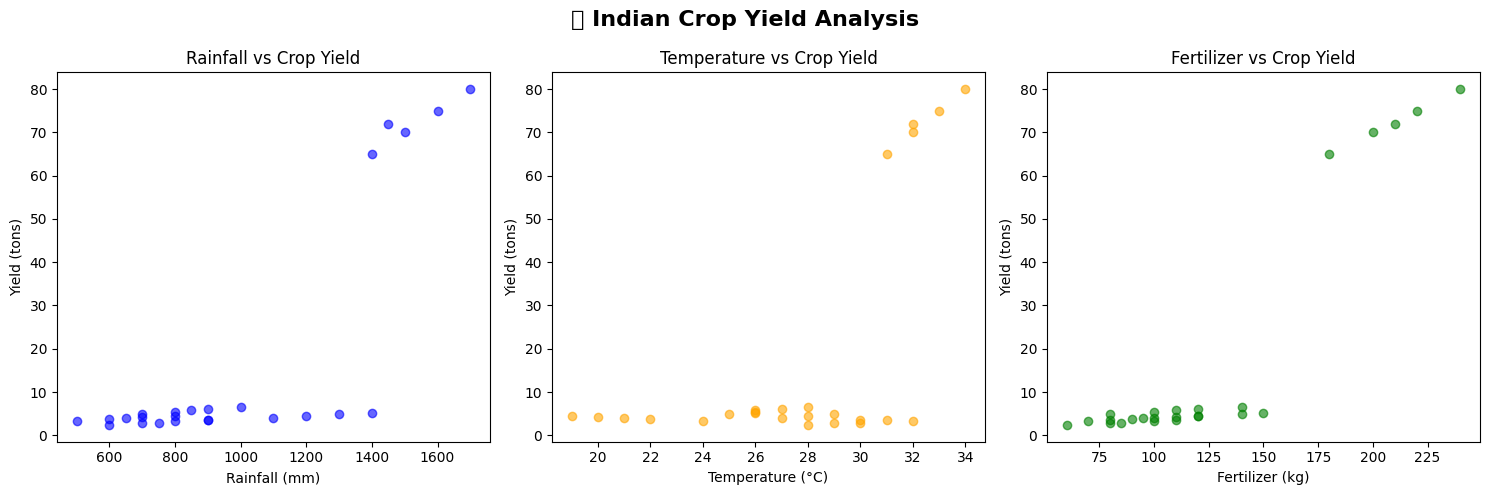

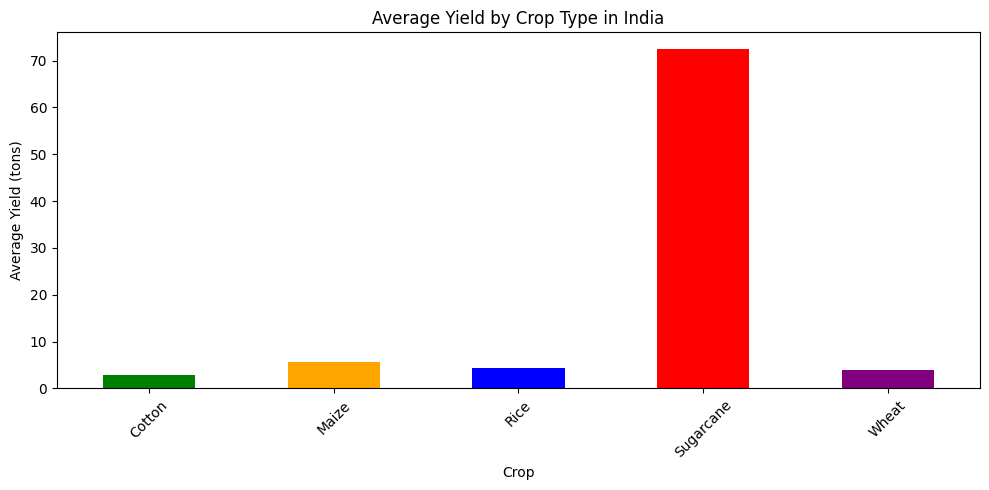

✅ Project Complete!
Built by Nandini Reddy - BTech CSE 1st Year


In [11]:
# Graph 1 - Rainfall vs Yield
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(df['rainfall_mm'], df['yield_tons'], color='blue', alpha=0.6)
axes[0].set_title('Rainfall vs Crop Yield')
axes[0].set_xlabel('Rainfall (mm)')
axes[0].set_ylabel('Yield (tons)')

# Graph 2 - Temperature vs Yield
axes[1].scatter(df['temperature_celsius'], df['yield_tons'], color='orange', alpha=0.6)
axes[1].set_title('Temperature vs Crop Yield')
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_ylabel('Yield (tons)')

# Graph 3 - Fertilizer vs Yield
axes[2].scatter(df['fertilizer_kg'], df['yield_tons'], color='green', alpha=0.6)
axes[2].set_title('Fertilizer vs Crop Yield')
axes[2].set_xlabel('Fertilizer (kg)')
axes[2].set_ylabel('Yield (tons)')

plt.suptitle('🌾 Indian Crop Yield Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# Graph 4 - Average yield by crop
avg_yield = df.groupby('crop')['yield_tons'].mean()
plt.figure(figsize=(10,5))
avg_yield.plot(kind='bar', color=['green','orange','blue','red','purple'])
plt.title('Average Yield by Crop Type in India')
plt.xlabel('Crop')
plt.ylabel('Average Yield (tons)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("✅ Project Complete!")
print("Built by Nandini Reddy - BTech CSE 1st Year")